# **Red Neuronal (Ojo del Oráculo)**

Este notebook tiene como objetivo entrenar una red neuronal para poder predecir si un equipo de héroes tendra exito en una misión del bosque maldito de belatz

In [69]:
!pip install shap

Librerias necesarias para realizar la Red Neuronal

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Activation
from sklearn.utils import class_weight
import seaborn as sns
from sklearn.metrics import roc_curve, auc

Cargamos el pergamino

In [71]:
df = pd.read_csv('bosque_maldito_limpio.csv')

Congelar el azar básico de python

In [72]:
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)

Congelar el azar de las matemáticas y el barajado interno

In [73]:
np.random.seed(42)

Congelar el azar del cerebro de la Red Neuronal (TensorFlow)

In [74]:
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

**Nuevas variables**

En lugar de darle a la red solo los datos crudos creamos nuevas variables que resumen el estado del equipo, la red aprende mejor con esta información procesada

* La suma de todas las estadisiticas de todos lo heroes presentes en el grupo (total_vida_equipo, total_mana, total_fisico etc). A la red le importa más saber si el equipo en total tiene mucho daño que saber cuanto daño tiene un equipo que saber cuanto daño tiene un héroe en individual, que quizas no está en la misión

* ratio_vida_mana: Divide la vida total entre el manal total, con esto sabemos si el equipo es tanque o mágico

* promedio_vida: vida total dividida por el número del héroes. Diferencia entre mucho héroes debiles y pocos héroes fuertes.

* sinergia_tanque_healer: verifica si al menos hay un tanque y un curandero. Esta combinación aumenta la supervivencia.

* sinergia_full_magic: verifica si estan los dos magos poderosos juntos

* equipo_rapido: verifica si la agilidad total es mayor que el fisico total (equipo de sigilo)

Lista de héroes disponibles

In [75]:
heroes = ['olenthero', 'thorgin', 'amalyria', 'basajorn', 'lamyreth', 'sugarth']

La red aprenderá mejor si sabe el total de vida o daño del equipo activo, no solo los valores sueltos de cada uno.

In [76]:
df['total_vida_equipo'] = 0
df['total_mana_equipo'] = 0
df['total_fisico_equipo'] = 0
df['total_agilidad_equipo'] = 0
df['tamano_equipo'] = 0

In [77]:
for hero in heroes:
    esta_en_equipo = df[f'{hero}_en_equipo']

    df['total_vida_equipo'] += df[f'{hero}_vida'] * esta_en_equipo
    df['total_mana_equipo'] += df[f'{hero}_mana'] * esta_en_equipo
    df['total_fisico_equipo'] += df[f'{hero}_fisico'] * esta_en_equipo
    df['total_agilidad_equipo'] += df[f'{hero}_agilidad'] * esta_en_equipo
    df['tamano_equipo'] += esta_en_equipo

Evitamos dividir por cero asi que sumamos un pequeño epsilon 0.001

In [78]:
df['ratio_vida_mana'] = df['total_vida_equipo'] / (df['total_mana_equipo'] + 0.001)
df['ratio_fisico_agilidad'] = df['total_fisico_equipo'] / (df['total_agilidad_equipo'] + 0.001)

Promedio de estadísticas por héroe (Calidad vs Cantidad)

In [79]:
df['promedio_vida'] = df['total_vida_equipo'] / (df['tamano_equipo'] + 0.001)

Aquí aplicamos reglas de RPG: Healer + Tanque suele ser buena combinación.

* Basajorn y Thorgin suelen ser Tanques/Físicos
* Amalyria es Healer/Maga
* Lamyreth es Pícaro/Agilidad

Verificamos si (Basajorn O Thorgin están) Y (Amalyria está) Tanque + healer

In [80]:
tiene_tanque = (df['basajorn_en_equipo'] == 1) | (df['thorgin_en_equipo'] == 1)
tiene_healer = (df['amalyria_en_equipo'] == 1)
df['sinergia_tanque_healer'] = (tiene_tanque & tiene_healer).astype(int)

¿Están Olenthero y Amalyria juntos? Full magic

In [81]:
df['sinergia_full_magic'] = ((df['olenthero_en_equipo'] == 1) & (df['amalyria_en_equipo'] == 1)).astype(int)

¿Muchos heroes de agilidad? Si la agilidad supera al fisico total es un quipo de sigilo/rápido

In [82]:
df['equipo_rapido'] = (df['total_agilidad_equipo'] > df['total_fisico_equipo']).astype(int)

In [83]:
print("--- ALQUIMIA COMPLETADA ---")
print("Nuevas variables creadas:")
print(df.columns[-10:])

--- ALQUIMIA COMPLETADA ---
Nuevas variables creadas:
Index(['total_mana_equipo', 'total_fisico_equipo', 'total_agilidad_equipo',
       'tamano_equipo', 'ratio_vida_mana', 'ratio_fisico_agilidad',
       'promedio_vida', 'sinergia_tanque_healer', 'sinergia_full_magic',
       'equipo_rapido'],
      dtype='object')


**Preprocesamiento de datos**

In [84]:
X = df.drop(['exito', 'mazmorra'], axis=1)
y = df['exito']

Separamos las caracteristicas (X) del objetivo (y), exito es lo que queremos predecir, "mazmorra" es un texto que no sirve para el cálculo matemático, a si que lo quitamos.

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Se reserva un 20% de los datos para Test y se usa el 80% para entrenar. Esto asegura que evaluamos la red con misiones que nunca ha visto antes.

Transformamos los datos para que todos tengan una escala similar promedio 0 y desviación estándar 1.

Si tenemos "Vida = 2000" y "Ataque = 5", la red pensará que la vida es más importante solo porque el número es más grande. El escalado corrige esto.

In [86]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
print(f"Dimensiones de entrada: {X_train.shape[1]} atributos")

Dimensiones de entrada: 42 atributos


**Modelado**

El código entrena primero una LogisticRegression. Nos sirve como punto de referencia, para saber que si nuestra red neuronal no supera a este modelo básico, entonces estamos haciendo algo mal.

Hemos considerado dejar un baseline básico en este notebook ya que introducimos nuevas variables muy potentes.

In [88]:
baseline = LogisticRegression()
baseline.fit(X_train_scaled, y_train)

LogisticRegression()

In [89]:
y_pred_base = baseline.predict(X_test_scaled)
acc_base = accuracy_score(y_test, y_pred_base)
print(f"Precisión del Baseline (Referencia): {acc_base:.2f}")

Precisión del Baseline (Referencia): 0.86


**Mecanismos de control**

In [90]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

Early stopping es un mecanismo para que la red deje de aprender cuando llega a su maximo estudio.
En este código hemos puesto un margen de confianza de 10 epocas, si en 10 intentos el error no baja el entrenamiento se detiene
Con esto evitamos el sobreajuste impide que la red aprenda de memoria los datos del entrenamiento

ReduceROnPlateau permite que el modelo ajuste fino, ayuda a encontrar el punto exacto de máxima precisión.

Mientras el EarlyStopping decide cuándo dejar de estudiar para no saturarse, el ReduceLROnPlateau decide cuándo ir más despacio para fijarse en los detalles más difíciles de los datos.

**Red Neuronal**

Creamos un contenedor vacío

In [91]:
model = Sequential()

Añadimos capas de neuronas "densas", significa que todas las neuronas de esta capa estan conectadas con todas las neuronas de la capa anterior

DropOut sirve para que la red no memorice los datos de entrenamiento. Durante el entrenamiento se apagan neuronas al azar para que el modelo aprenda patrones generales y no detalles especificos

La normalización por lotes ayuda a que la red aprenda de forma más estable y rápida ajustando los valores que pasan entre capas

In [92]:
model.add(Dense(64, input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [93]:
model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.3))

In [94]:
model.add(Dense(1, activation='sigmoid'))

In [95]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

EL optimizador es el algoritmo encargado de corregir a la red neuronal.
Cuando la red se equivoca en una predicción, el optimizador decide cómo ajustar los "pesos" (la importancia de las conexiones entre neuronas) para que la próxima vez se equivoque menos.

In [96]:
pesos = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(pesos))

print(f"Pesos Sagrados: {class_weights_dict}")

Pesos Sagrados: {0: np.float64(0.5646853146853147), 1: np.float64(4.364864864864865)}


Este trozo de código es importante ya que en nuestro caso la mayoria de la misiones son derrotas. Si entrenamos la red neuronal sin más, descubre un truco vago: si predice siempre Fracaso acierta el 90% de la veces si enfuerzo, y lo que nosotros queremos es detectar esos exitos raros.

class_weight='balanced': calcula un peso inversamente proporcional a la frecuencia, es decir, si hay algo muy común, vale poco. Si algo es muy raro, vale mucho

Aqui es donde entrenamos el modelo

In [97]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping,reduce_lr],
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5969 - loss: 0.9733 - val_accuracy: 0.4308 - val_loss: 0.7339 - learning_rate: 0.0010
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6031 - loss: 0.7545 - val_accuracy: 0.4846 - val_loss: 0.7009 - learning_rate: 0.0010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5711 - loss: 0.8121 - val_accuracy: 0.5615 - val_loss: 0.6832 - learning_rate: 0.0010
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5478 - loss: 0.7594 - val_accuracy: 0.6154 - val_loss: 0.6702 - learning_rate: 0.0010
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6239 - loss: 0.7586 - val_accuracy: 0.6000 - val_loss: 0.6582 - learning_rate: 0.0010
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6446 - loss: 0.6900 - val_accuracy: 0.5923 - val_loss: 0.6603 - learning_rate: 0.0010
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6322 - loss: 0.6975 - 

Es la instruccion que le dice a la inteligencia artificial que comience a aprender de nuestros datos

El parámetro fit es la que ejecuta el entrenamiento y se guarda en la variable history. X_train_scaled, y_train son las variables que el modelo utiliza para aprender,X_train_scaled es la variable que utiliza para predecir y la otra es la respuesta correcta o etiqueta que en nuetsro caso intenta predecir

Como podemos ver el modelo paró en la época 27, esto quiere decir que dejó de aprender cosas útiles en esta época.

Aunque entrenó hasta la época 27, el modelo se dio cuenta de que su mejor momento fue en la época 17. Todo lo que hizo de la época 11 a la 20 no sirvió para mejorar en datos nuevos, así que de forma muy inteligente, descartó esos últimos intentos y volvió a la configuración de la época 10.

(accuracy: 0.6607) como la de validación (val_accuracy: 0.6493) rondan el 60%. Al ser tan parecidas, sabemos que el modelo no está sobreajustado.

Estos datos son lógicos, ya que como vimos la mayoria de las incursiones son derrotas. Como hemos ajustado los pesos de las clases para que no prediga que siempre es derrota. Al arriesgarse a predecir "éxito" más a menudo, se equivoca más y su accuracy general baja a ese 60%, pero sus predicciones son mucho más valiosas.

In [98]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\n--- RESULTADOS DEL ORÁCULO MEJORADO ---")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7185 - loss: 0.5975

--- RESULTADOS DEL ORÁCULO MEJORADO ---
Pérdida (Loss): 0.6054
Precisión (Accuracy): 0.7037


Una vez que hemos entrenado a nuestro modelo y rescatado su mejor versión (época 17), es el momento de someterlo a su prueba final utilizando el método .evaluate().

Para esto, utilizaremos nuestro conjunto de datos de prueba (`X_test_scaled` y `y_test`). Es crucial destacar que el modelo nunca ha visto estos datos durante su entrenamiento; representan incursiones a la mazmorra completamente nuevas. Evaluar el modelo en datos no vistos es la única forma de comprobar si realmente ha aprendido a generalizar los patrones de éxito y fracaso, o si simplemente memorizó los datos anteriores.

A continuación, imprimimos las métricas generales de Pérdida (*Loss*) y Precisión (*Accuracy*). Sin embargo, recordando el desbalanceo de nuestras clases alta tasa de mortalidad en las mazmorras, cogemos esta Precisión general solo como un primer vistazo antes de profundizar en métricas más específicas.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


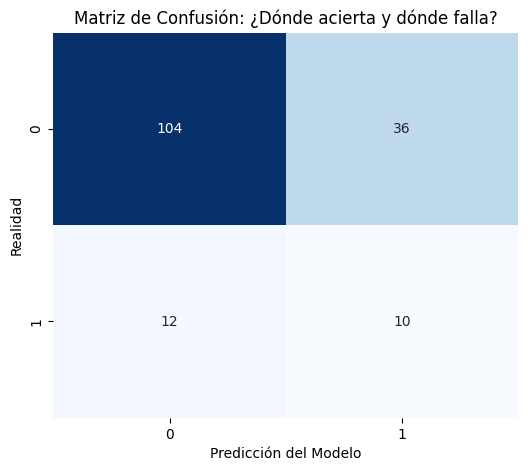

In [99]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión: ¿Dónde acierta y dónde falla?')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

Arriba a la izquierda. El modelo predijo que el equipo perdería, y efectivamente habrían perdido. El modelo salvó a 103 equipos de una muerte segura.

Arriba a la derecha. El modelo dijo "Van a ganar", pero la realidad es que el equipo fue aniquilado. Esta es la métrica más peligrosa. Al usar los class_weights para forzar al modelo a buscar victorias, se volvió demasiado optimista y mandó a 36 equipos al desastre.

Abajo a la izquierda. El modelo predijo una derrota y aconsejó no entrar, pero la realidad es que esos 12 equipos tenían la composición perfecta para ganar.

Abajo a la derecha. El modelo predijo victoria y el equipo realmente triunfó.

Aunque la precisión general rondaba el 60%, la precisión real para la clase minoritaria "Victoria" es muy baja. El modelo actual sirve como un buen filtro para descartar equipos terribles, pero no es lo suficientemente confiable para garantizar el éxito de una incursión.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


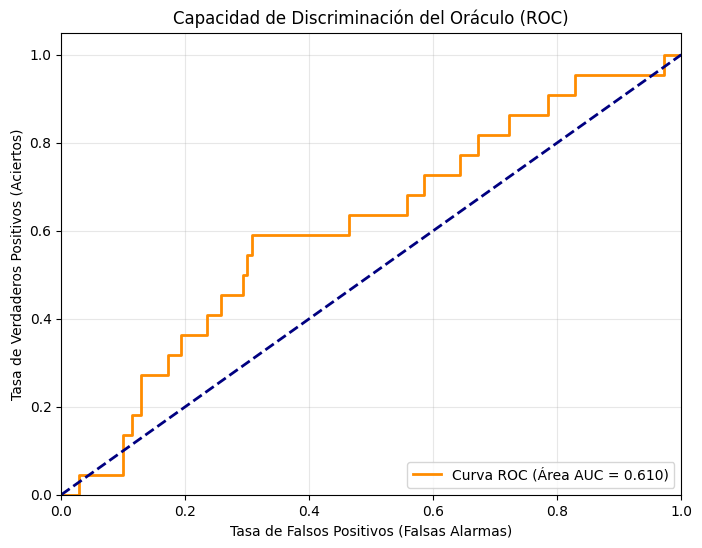

Interpretación: Un AUC de 0.610 significa que el modelo tiene un 61.0% de probabilidad de ordenar correctamente un caso de éxito frente a uno de fracaso.


In [100]:
y_pred_keras = model.predict(X_test_scaled).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_keras)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (Área AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Falsas Alarmas)')
plt.ylabel('Tasa de Verdaderos Positivos (Aciertos)')
plt.title('Capacidad de Discriminación del Oráculo (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Interpretación: Un AUC de {roc_auc:.3f} significa que el modelo tiene un {(roc_auc*100):.1f}% de probabilidad de ordenar correctamente un caso de éxito frente a uno de fracaso.")

La Matriz de Confusión anterior evaluaba las decisiones de nuestro Oráculo utilizando un umbral por defecto del 50% de probabilidad. Sin embargo, en escenarios de alto riesgo como la exploración de mazmorras.

Para ello, extraemos las probabilidades continuas (entre 0 y 1) de las predicciones del modelo y construimos una Curva ROC.

* La línea azul: Representa la suerte aleatoria.
* La línea naranja: Podemos ver que va serpenteando y cruzándose con la línea azul todo el tiempo. Intenta despegarse hacia arriba que es donde están los aciertos puros.

La precisión del 60% del principio era totalmente una ilusión causada por intentar predecir una clase más que la otra. La realidad es que la red neuronal no está logrando encontrar ningún patrón útil en los datos de tus héroes para predecir la victoria.

**SHAP**

Las redes neuronales son modelos de "caja negra"; nos dan una predicción, pero no justifican su razonamiento. Dado que nuestro modelo ha alcanzado un AUC de 0.61 (superando el umbral aleatorio y demostrando capacidad de aprendizaje), es el momento de descubrir qué patrones ha encontrado en la mazmorra.

Para ello, utilizaremos SHAP (SHapley Additive exPlanations), un método basado en la teoría de juegos cooperativos que asigna a cada variable un valor de importancia para cada predicción.

**Metodología:**
1. **Fondo representativo:** Para optimizar el coste computacional (SHAP es muy intensivo), utilizamos `K-Means` para resumir el conjunto de entrenamiento en 50 muestras representativas.
2. **Explicador Kernel:** Usamos un `KernelExplainer` para interrogar a la red neuronal y ver cómo varían sus predicciones al alterar las características de los héroes.
3. **Gráfico de Enjambre (Beeswarm):** Calculamos los valores SHAP para una muestra de prueba y los visualizamos.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
157/157 ━━━━

/tmp/ipython-input-3979552499.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


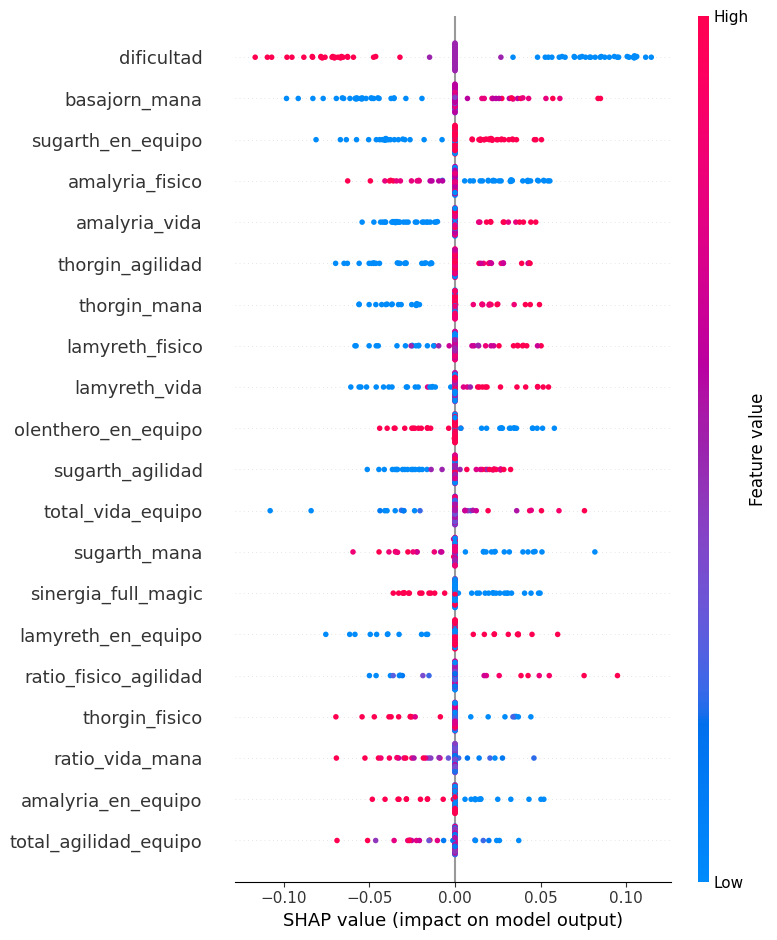

In [101]:
import shap

background = shap.kmeans(X_train_scaled, 50)

explainer = shap.KernelExplainer(model.predict, background)

shap_values = explainer.shap_values(X_test_scaled[:100], nsamples=100)

print("\n--- ANÁLISIS DE IMPORTANCIA DE VARIABLES (SHAP) ---")
print("Lado DERECHO: Influye positivamente en el ÉXITO.")
print("Lado IZQUIERDO: Influye negativamente (causa FRACASO).")
print("Color ROJO: Valor alto de esa característica.")
print("Color AZUL: Valor bajo de esa característica.")

plt.figure()

shap.summary_plot(
    shap_values.squeeze(),
    X_test_scaled[:100],
    feature_names=X.columns.tolist(),
    show=True
)

* **El peso de la Dificultad:** La variable dificultad es el predictor más fuerte. Incursiones de alta dificultad puntos rojos reducen drásticamente la probabilidad de éxito.

* **Héroes Clave y Atributos:** Basajorn y Sugarth Son fundamentales para la supervivencia. Un alto nivel de maná en Basajorn basajorn_mana y la simple presencia de Sugarth sugarth_en_equipo son los mayores impulsores hacia la victoria.
    * **El rol de Amalyria:** El modelo penaliza fuertemente las composiciones donde Amalyria tiene un alto valor físico amalyria_fisico. Su supervivencia amalyria_vida es importante, pero no su daño físico.
* **Efectividad de la Ingeniería de Características:** Las variables sintéticas generadas, como sinergia_full_magic, demuestran poder predictivo. Curiosamente, el modelo ha aprendido que una composición exclusivamente mágica correlaciona con la derrota (los valores altos penalizan la predicción), probablemente por falta de resistencia física frontal.

**Importación del modelo**

In [102]:
model.save('ojo_del_oraculo.h5')
joblib.dump(scaler, 'scaler_oraculo.pkl')

['scaler_oraculo.pkl']